# Analyze Progressive Self-Play

Notebook nay doc du lieu self-play trong `outputs/progressive_self_play`, tong hop theo batch/episode/step, va ve cac thong ke chinh:

- phan phoi action tong the
- heatmap action 5x5 cho `(acceleration_idx, steering_idx)`
- phan phoi theo worker
- do dai episode
- policy entropy va chosen-action probability
- phan phoi value target

Mac dinh notebook **khong** load toan bo `states` vao RAM, chi doc metadata, `actions`, `policies`, `values`. Co cell rieng de xem state tensor khi can.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

plt.style.use("ggplot")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

ROOT = Path("/home/namph32/workspace/Autonomous-Driving-Gym/legacy/AlphaZero-based-autonomous-driving/outputs/progressive_self_play")
BATCH_NAME_FILTER: str | None = None
ACTIONS_PER_AXIS = 5
AXIS_VALUES = np.linspace(-1.0, 1.0, ACTIONS_PER_AXIS)

assert ROOT.exists(), f"Missing self-play root: {ROOT}"
ROOT

PosixPath('/home/namph32/workspace/Autonomous-Driving-Gym/legacy/AlphaZero-based-autonomous-driving/outputs/progressive_self_play')

In [2]:
def load_manifest(manifest_path: Path) -> dict:
    return json.loads(manifest_path.read_text(encoding="utf-8"))


def discover_manifests(root: Path, batch_name_filter: str | None = None) -> list[Path]:
    manifests = sorted(root.glob("*/manifest.json"))
    if batch_name_filter:
        manifests = [path for path in manifests if path.parent.name == batch_name_filter]
    return manifests


def decode_action(action_id: int, actions_per_axis: int = ACTIONS_PER_AXIS) -> dict:
    acceleration_idx, steering_idx = divmod(int(action_id), actions_per_axis)
    acceleration_value = float(AXIS_VALUES[acceleration_idx])
    steering_value = float(AXIS_VALUES[steering_idx])
    return {
        "action_id": int(action_id),
        "acceleration_idx": acceleration_idx,
        "steering_idx": steering_idx,
        "acceleration_value": acceleration_value,
        "steering_value": steering_value,
        "action_label": f"a={acceleration_value:+.2f}, s={steering_value:+.2f}",
    }


def policy_entropy(policy_row: np.ndarray) -> float:
    probs = np.asarray(policy_row, dtype=np.float64)
    probs = np.clip(probs, 1e-12, 1.0)
    return float(-(probs * np.log(probs)).sum())


def summarize_self_play(root: Path, batch_name_filter: str | None = None):
    manifests = discover_manifests(root, batch_name_filter=batch_name_filter)
    if not manifests:
        raise FileNotFoundError(f"No manifest.json found under {root}")

    batch_rows: list[dict] = []
    episode_rows: list[dict] = []
    action_rows: list[dict] = []

    for manifest_path in manifests:
        manifest = load_manifest(manifest_path)
        batch_dir = manifest_path.parent
        summary = manifest.get("summary", {})
        batch_rows.append(
            {
                "iteration": int(manifest.get("iteration", -1)),
                "batch_name": manifest.get("batch_name", batch_dir.name),
                "created_at_utc": manifest.get("created_at_utc"),
                "episode_count": int(summary.get("episode_count", 0)),
                "sample_count": int(summary.get("sample_count", 0)),
                "total_steps": int(summary.get("total_steps", 0)),
                "avg_steps_per_episode": float(summary.get("avg_steps_per_episode", 0.0)),
                "manifest_path": str(manifest_path),
                "source_model": manifest.get("source_model", {}).get("filename"),
            }
        )

        for episode_meta in manifest.get("episodes", []):
            episode_path = batch_dir / episode_meta["path"]
            payload = torch.load(episode_path, map_location="cpu")
            actions = [int(action) for action in payload.get("actions", [])]
            policies = torch.as_tensor(payload["policies"], dtype=torch.float32).numpy()
            values = torch.as_tensor(payload["values"], dtype=torch.float32).view(-1).numpy()

            episode_row = {
                "iteration": int(manifest.get("iteration", -1)),
                "batch_name": manifest.get("batch_name", batch_dir.name),
                "worker_id": int(payload.get("worker_id", episode_meta.get("worker_id", -1))),
                "episode_index": int(payload.get("episode_index", episode_meta.get("episode_index", -1))),
                "self_play_seed": int(payload.get("self_play_seed", episode_meta.get("self_play_seed", -1))),
                "sample_count": int(episode_meta.get("sample_count", len(actions))),
                "steps": int(episode_meta.get("steps", len(actions))),
                "state_shape": tuple(episode_meta.get("state_shape", [])),
                "policy_shape": tuple(episode_meta.get("policy_shape", [])),
                "value_shape": tuple(episode_meta.get("value_shape", [])),
                "outcome": float(values[-1]) if len(values) else np.nan,
                "mean_policy_entropy": float(np.mean([policy_entropy(row) for row in policies])) if len(policies) else np.nan,
                "mean_max_policy_prob": float(np.mean(np.max(policies, axis=1))) if len(policies) else np.nan,
                "episode_path": str(episode_path),
            }
            episode_rows.append(episode_row)

            for step_idx, action_id in enumerate(actions):
                policy_row = policies[step_idx]
                action_info = decode_action(action_id)
                action_rows.append(
                    {
                        "iteration": episode_row["iteration"],
                        "batch_name": episode_row["batch_name"],
                        "worker_id": episode_row["worker_id"],
                        "episode_index": episode_row["episode_index"],
                        "self_play_seed": episode_row["self_play_seed"],
                        "step_idx": step_idx,
                        "chosen_action_prob": float(policy_row[action_id]),
                        "max_policy_prob": float(np.max(policy_row)),
                        "policy_entropy": policy_entropy(policy_row),
                        "value_target": float(values[step_idx]) if step_idx < len(values) else np.nan,
                        **action_info,
                    }
                )

    batch_df = pd.DataFrame(batch_rows).sort_values(["iteration", "batch_name"]).reset_index(drop=True)
    episode_df = pd.DataFrame(episode_rows).sort_values(["iteration", "worker_id", "episode_index"]).reset_index(drop=True)
    action_df = pd.DataFrame(action_rows).sort_values(["iteration", "worker_id", "episode_index", "step_idx"]).reset_index(drop=True)
    return batch_df, episode_df, action_df


batch_df, episode_df, action_df = summarize_self_play(ROOT, batch_name_filter=BATCH_NAME_FILTER)
print(f"batches={len(batch_df)} episodes={len(episode_df)} steps={len(action_df)}")

batches=1 episodes=8 steps=959


In [3]:
display(batch_df)
display(episode_df.head(20))
display(action_df.head(20))

print("Overall summary")
print(f"  total batches   : {len(batch_df)}")
print(f"  total episodes  : {len(episode_df)}")
print(f"  total decisions : {len(action_df)}")
print(f"  mean steps/ep   : {episode_df['steps'].mean():.2f}")
print(f"  outcome counts  :\n{episode_df['outcome'].value_counts(dropna=False).sort_index()}")

,iteration,batch_name,created_at_utc,episode_count,sample_count,total_steps,avg_steps_per_episode,manifest_path,source_model
0,1,iter_0001,2026-03-25T07:29:55Z,8,959,959,119.875,/home/namph32/workspace/Autonomous-Driving-Gym...,model_iter_0000.pth


,iteration,batch_name,worker_id,episode_index,self_play_seed,sample_count,steps,state_shape,policy_shape,value_shape,outcome,mean_policy_entropy,mean_max_policy_prob,episode_path
0,1,iter_0001,0,0,1000,336,336,"(336, 8, 100, 24)","(336, 25)","(336, 1)",-1.0,3.021978,0.126295,/home/namph32/workspace/Autonomous-Driving-Gym...
1,1,iter_0001,0,1,1001,400,400,"(400, 8, 100, 24)","(400, 25)","(400, 1)",0.0,3.037310,0.124615,/home/namph32/workspace/Autonomous-Driving-Gym...
2,1,iter_0001,1,0,11000,9,9,"(9, 8, 100, 24)","(9, 25)","(9, 1)",-1.0,2.964243,0.141688,/home/namph32/workspace/Autonomous-Driving-Gym...
3,1,iter_0001,1,1,11001,18,18,"(18, 8, 100, 24)","(18, 25)","(18, 1)",-1.0,3.039581,0.097268,/home/namph32/workspace/Autonomous-Driving-Gym...
4,1,iter_0001,2,0,21000,48,48,"(48, 8, 100, 24)","(48, 25)","(48, 1)",-1.0,2.853586,0.165429,/home/namph32/workspace/Autonomous-Driving-Gym...
5,1,iter_0001,2,1,21001,11,11,"(11, 8, 100, 24)","(11, 25)","(11, 1)",-1.0,3.097610,0.094488,/home/namph32/workspace/Autonomous-Driving-Gym...
6,1,iter_0001,3,0,31000,49,49,"(49, 8, 100, 24)","(49, 25)","(49, 1)",-1.0,2.801762,0.182916,/home/namph32/workspace/Autonomous-Driving-Gym...
7,1,iter_0001,3,1,31001,88,88,"(88, 8, 100, 24)","(88, 25)","(88, 1)",-1.0,3.100465,0.105253,/home/namph32/workspace/Autonomous-Driving-Gym...


,iteration,batch_name,worker_id,episode_index,self_play_seed,step_idx,chosen_action_prob,max_policy_prob,policy_entropy,value_target,action_id,acceleration_idx,steering_idx,acceleration_value,steering_value,action_label
0,1,iter_0001,0,0,1000,0,0.030075,0.077694,3.168863,-1.0,4,0,4,-1.0,1.0,"a=-1.00, s=+1.00"
1,1,iter_0001,0,0,1000,1,0.055961,0.111922,3.135660,-1.0,12,2,2,0.0,0.0,"a=+0.00, s=+0.00"
2,1,iter_0001,0,0,1000,2,0.035545,0.087678,3.164133,-1.0,11,2,1,0.0,-0.5,"a=+0.00, s=-0.50"
3,1,iter_0001,0,0,1000,3,0.031401,0.118357,3.118427,-1.0,13,2,3,0.0,0.5,"a=+0.00, s=+0.50"
4,1,iter_0001,0,0,1000,4,0.106796,0.123786,3.099164,-1.0,13,2,3,0.0,0.5,"a=+0.00, s=+0.50"
5,1,iter_0001,0,0,1000,5,0.031603,0.135440,3.114221,-1.0,2,0,2,-1.0,0.0,"a=-1.00, s=+0.00"
6,1,iter_0001,0,0,1000,6,0.041162,0.108959,3.128862,-1.0,0,0,0,-1.0,-1.0,"a=-1.00, s=-1.00"
7,1,iter_0001,0,0,1000,7,0.031250,0.081731,3.170827,-1.0,22,4,2,1.0,0.0,"a=+1.00, s=+0.00"
8,1,iter_0001,0,0,1000,8,0.058252,0.070388,3.177091,-1.0,7,1,2,-0.5,0.0,"a=-0.50, s=+0.00"
9,1,iter_0001,0,0,1000,9,0.030733,0.118203,3.139415,-1.0,13,2,3,0.0,0.5,"a=+0.00, s=+0.50"


Overall summary
  total batches   : 1
  total episodes  : 8
  total decisions : 959
  mean steps/ep   : 119.88
  outcome counts  :
outcome
-1.0    7
 0.0    1
Name: count, dtype: int64


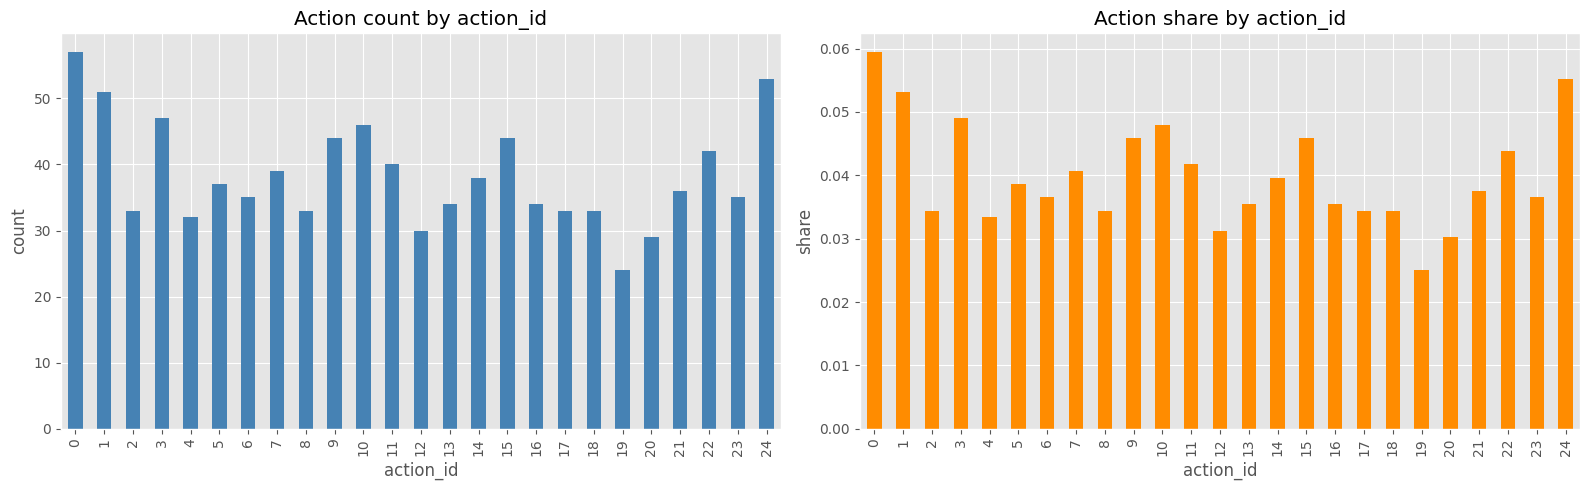

,count,share
action_id,,
0,57,5.94%
1,51,5.32%
2,33,3.44%
3,47,4.90%
4,32,3.34%
5,37,3.86%
6,35,3.65%
7,39,4.07%
8,33,3.44%


In [4]:
action_counts = action_df['action_id'].value_counts().sort_index()
action_share = action_counts / action_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
action_counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Action count by action_id')
axes[0].set_xlabel('action_id')
axes[0].set_ylabel('count')

action_share.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Action share by action_id')
axes[1].set_xlabel('action_id')
axes[1].set_ylabel('share')
plt.tight_layout()
plt.show()

display(pd.DataFrame({'count': action_counts, 'share': action_share}).style.format({'share': '{:.2%}'}))

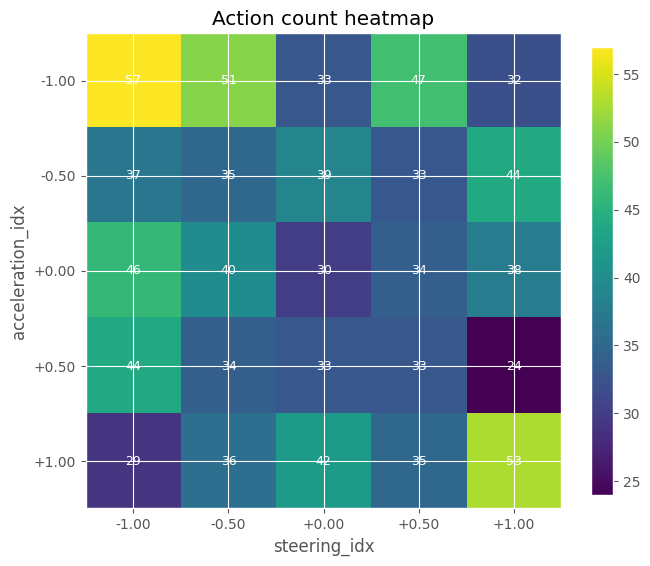

steering_idx,0,1,2,3,4
acceleration_idx,,,,,
0,57,51,33,47,32
1,37,35,39,33,44
2,46,40,30,34,38
3,44,34,33,33,24
4,29,36,42,35,53


In [5]:
heatmap_counts = (
    action_df.groupby(['acceleration_idx', 'steering_idx'])['action_id']
    .count()
    .unstack(fill_value=0)
    .reindex(index=range(ACTIONS_PER_AXIS), columns=range(ACTIONS_PER_AXIS), fill_value=0)
)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(heatmap_counts.values, cmap='viridis')
ax.set_title('Action count heatmap')
ax.set_xlabel('steering_idx')
ax.set_ylabel('acceleration_idx')
ax.set_xticks(range(ACTIONS_PER_AXIS), labels=[f'{value:+.2f}' for value in AXIS_VALUES])
ax.set_yticks(range(ACTIONS_PER_AXIS), labels=[f'{value:+.2f}' for value in AXIS_VALUES])

for i in range(ACTIONS_PER_AXIS):
    for j in range(ACTIONS_PER_AXIS):
        ax.text(j, i, int(heatmap_counts.iloc[i, j]), ha='center', va='center', color='white', fontsize=9)

fig.colorbar(im, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()

heatmap_counts

In [ ]:
worker_action_share = (
    action_df.groupby(['worker_id', 'action_id'], as_index=False)['step_idx']
    .count()
    .rename(columns={'step_idx': 'count'})
)
worker_action_share['share'] = (
    worker_action_share['count']
    / worker_action_share.groupby('worker_id')['count'].transform('sum')
)

worker_pivot = worker_action_share.pivot(index='worker_id', columns='action_id', values='share').fillna(0.0)
display(worker_pivot.style.format('{:.2%}'))

episode_df[['worker_id', 'episode_index', 'steps', 'outcome', 'mean_policy_entropy', 'mean_max_policy_prob']].sort_values(['worker_id', 'episode_index'])

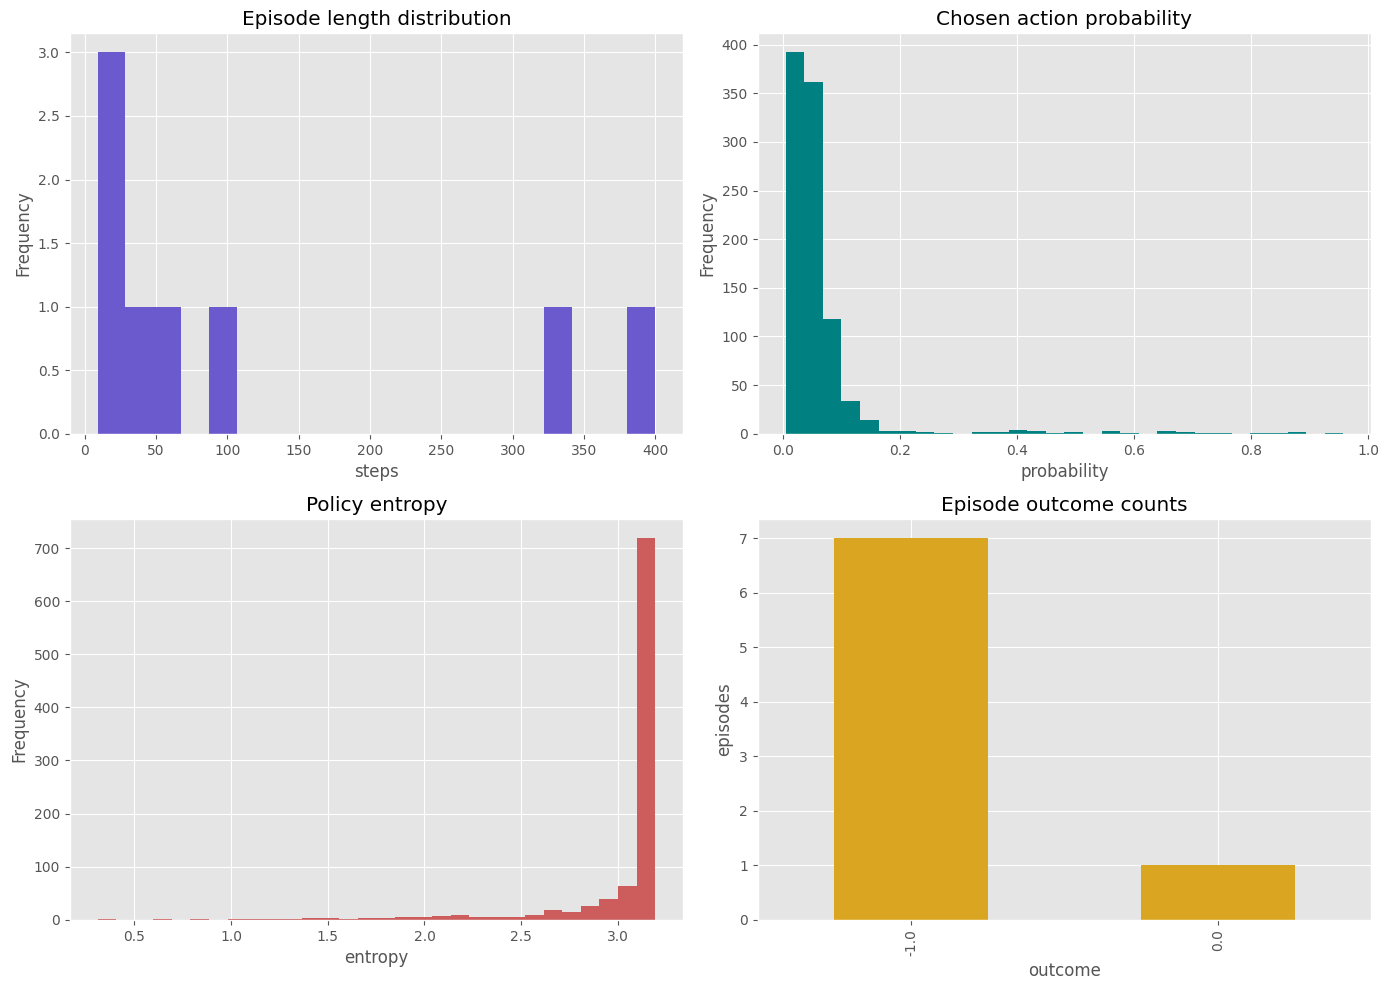

,chosen_action_prob,max_policy_prob,policy_entropy,value_target
count,959.000000,959.000000,959.000000,959.000000
mean,0.067092,0.127750,3.016551,-0.582899
std,0.100939,0.111518,0.356157,0.493337
min,0.004608,0.060386,0.309705,-1.000000
25%,0.031553,0.083237,3.096003,-1.000000
50%,0.041262,0.097324,3.140818,-1.000000
75%,0.063902,0.118644,3.159020,0.000000
max,0.957101,0.957101,3.193278,0.000000


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

episode_df['steps'].plot(kind='hist', bins=20, ax=axes[0, 0], color='slateblue')
axes[0, 0].set_title('Episode length distribution')
axes[0, 0].set_xlabel('steps')

action_df['chosen_action_prob'].plot(kind='hist', bins=30, ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Chosen action probability')
axes[0, 1].set_xlabel('probability')

action_df['policy_entropy'].plot(kind='hist', bins=30, ax=axes[1, 0], color='indianred')
axes[1, 0].set_title('Policy entropy')
axes[1, 0].set_xlabel('entropy')

episode_df['outcome'].value_counts().sort_index().plot(kind='bar', ax=axes[1, 1], color='goldenrod')
axes[1, 1].set_title('Episode outcome counts')
axes[1, 1].set_xlabel('outcome')
axes[1, 1].set_ylabel('episodes')

plt.tight_layout()
plt.show()

action_df[['chosen_action_prob', 'max_policy_prob', 'policy_entropy', 'value_target']].describe()

episode_path: /home/namph32/workspace/Autonomous-Driving-Gym/legacy/AlphaZero-based-autonomous-driving/outputs/progressive_self_play/iter_0001/episodes/worker_00_episode_000.pt
states: (336, 8, 100, 24) torch.float32
policies: (336, 25) torch.float32
values: (336, 1) torch.float32
actions head: [4, 12, 11, 13, 13, 2, 0, 22, 7, 13, 17, 23, 16, 3, 6, 15, 0, 2, 0, 0]


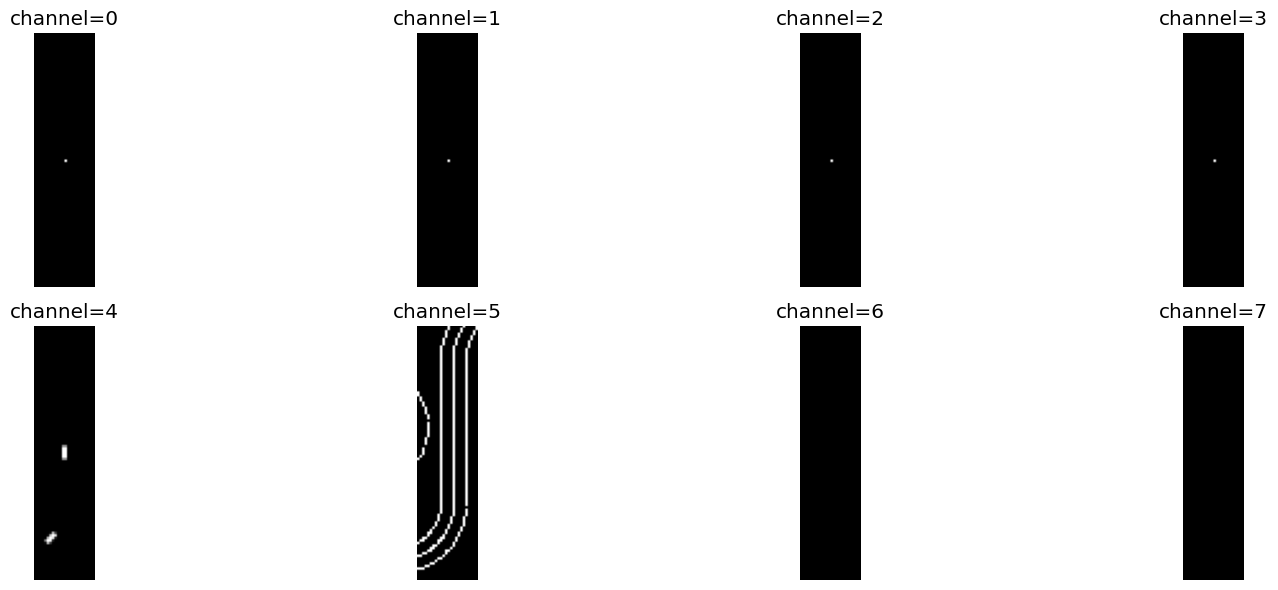

In [8]:
# Optional: inspect one episode payload and one sample state tensor.
episode_path = Path(episode_df.iloc[0]['episode_path'])
payload = torch.load(episode_path, map_location='cpu')
print('episode_path:', episode_path)
print('states:', tuple(payload['states'].shape), payload['states'].dtype)
print('policies:', tuple(payload['policies'].shape), payload['policies'].dtype)
print('values:', tuple(payload['values'].shape), payload['values'].dtype)
print('actions head:', payload['actions'][:20])

sample_index = 0
sample_state = payload['states'][sample_index].numpy()
n_channels = sample_state.shape[0]
fig, axes = plt.subplots(2, int(np.ceil(n_channels / 2)), figsize=(18, 6))
axes = np.asarray(axes).reshape(-1)
for channel_idx in range(n_channels):
    axes[channel_idx].imshow(sample_state[channel_idx], cmap='gray')
    axes[channel_idx].set_title(f'channel={channel_idx}')
    axes[channel_idx].axis('off')
for axis in axes[n_channels:]:
    axis.axis('off')
plt.tight_layout()
plt.show()